In [22]:
import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from pipeline_components import (
    DateFeatures,
    HardDropColumns,
    DropConstantColumns
)

In [23]:
DATA_PATH = "archive/Housing.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [24]:
print("Dataset Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nStatistical Summary")

display(df.describe())

Dataset Shape : (4600, 18)

Columns
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

Information
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


# Exploratory Data Analysis (EDA)

In this section, we explore the dataset using different visualizations to understand feature distributions, relationships and data quality before training the machine learning models.

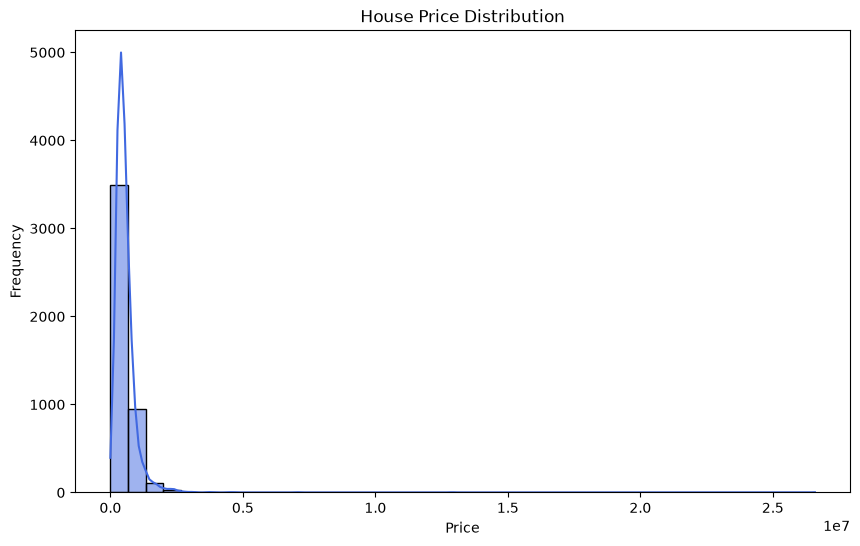

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("House Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

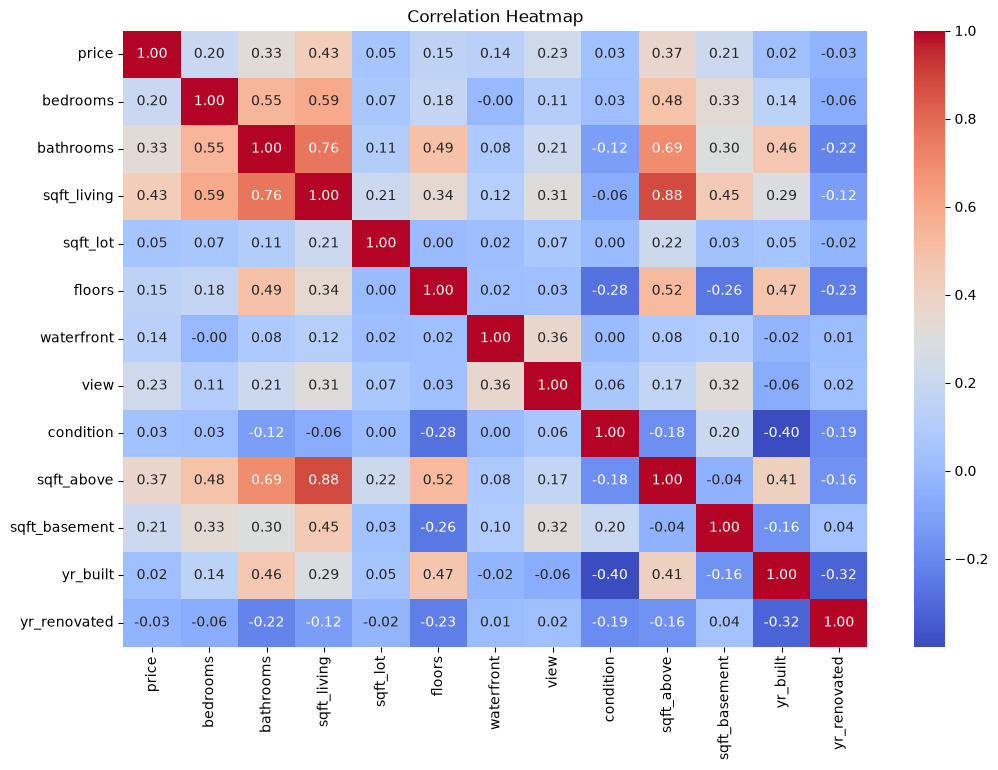

In [26]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

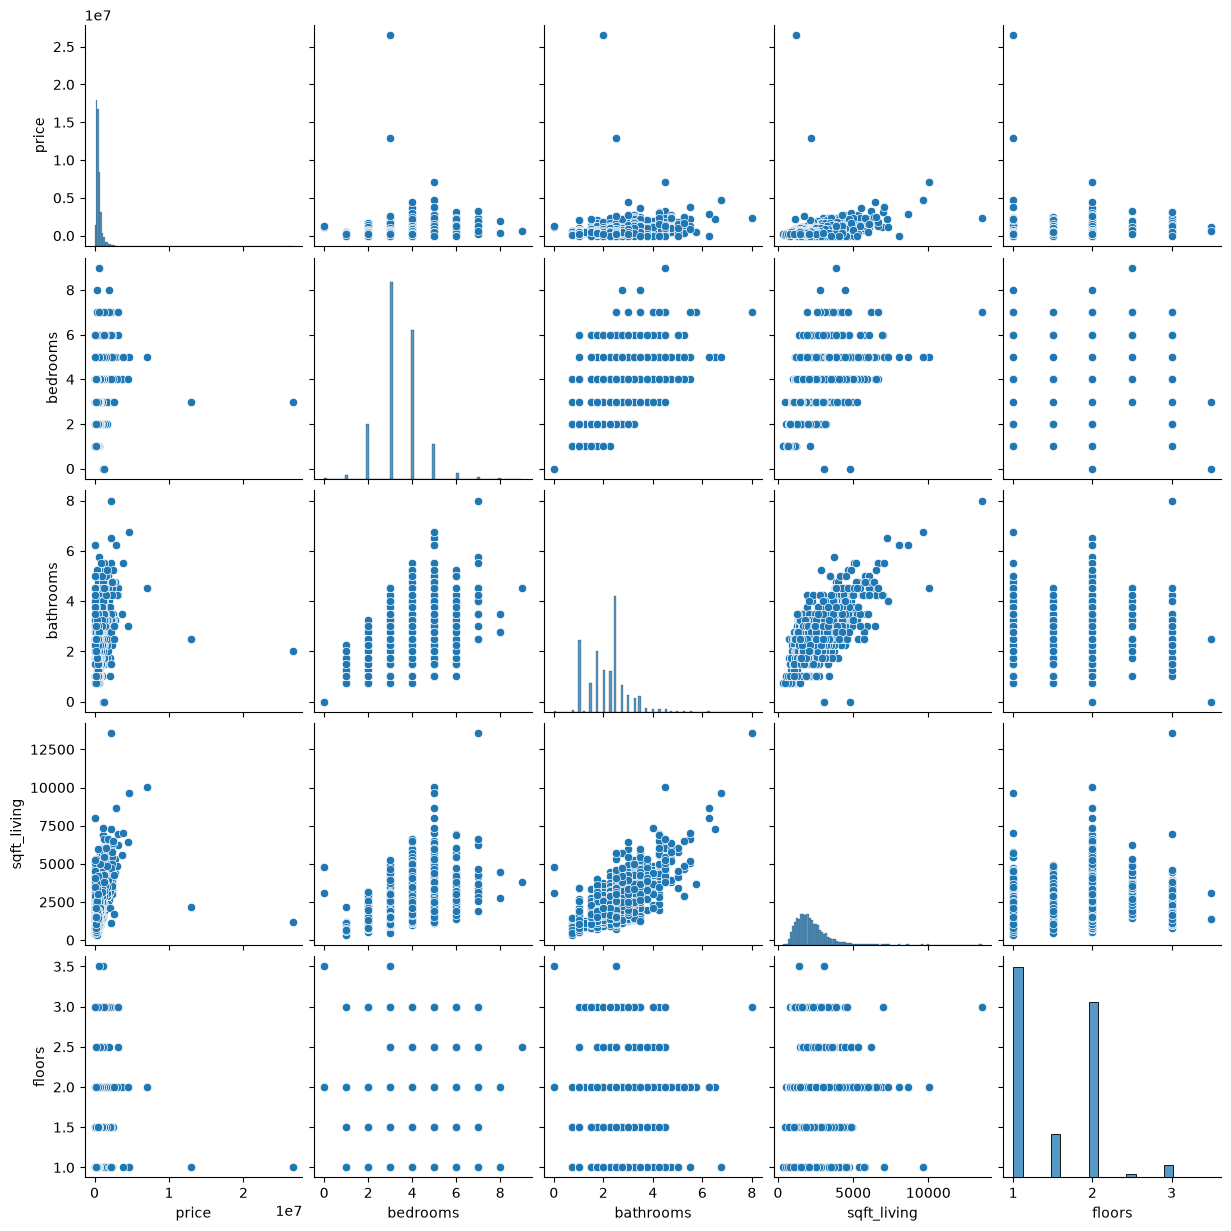

In [27]:
sns.pairplot(
    df[
        [
            "price",
            "bedrooms",
            "bathrooms",
            "sqft_living",
            "floors"
        ]
    ]
)

plt.show()

In [28]:
missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No Missing Values Found.")
else:
    plt.figure(figsize=(8,5))

    missing.plot(kind="bar")

    plt.title("Missing Values")

    plt.show()

✅ No Missing Values Found.


missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print(" No Missing Values Found.")
else:
    plt.figure(figsize=(8,5))

    missing.plot(kind="bar")

    plt.title("Missing Values")

    plt.show()

In [29]:
def build_preprocessing_pipeline(X):

    hard_drop = ["street"]

    categorical_cols = ["city", "statezip"]

    numeric_cols = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    if "price" in numeric_cols:
        numeric_cols.remove("price")

    column_transformer = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_cols
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_cols
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return Pipeline(
        steps=[
            ("date", DateFeatures(date_col="date")),
            ("hard_drop", HardDropColumns(cols=hard_drop)),
            ("drop_constant", DropConstantColumns(min_unique=2)),
            ("column_transform", column_transformer)
        ]
    )

In [30]:
X = df.drop(columns=["price"])

y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

preprocess = build_preprocessing_pipeline(X_train)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (3680, 17)
Testing Shape : (920, 17)


# Model Training

Three regression models are trained and evaluated:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Each model is trained using the same preprocessing pipeline.

In [31]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []

best_model = None
best_name = None
best_predictions = None
best_r2 = -999

In [32]:
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    print("="*50)
    print(name)
    print("="*50)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R² :", r2)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    if r2 > best_r2:

        best_r2 = r2

        best_name = name

        best_model = pipeline

        best_predictions = predictions

Linear Regression
MAE : 155719.90324952142
RMSE: 981709.6876999309
R² : 0.05500086332444565
Random Forest
MAE : 157810.82891155177
RMSE: 985676.0105004803
R² : 0.047349429529446985
Gradient Boosting
MAE : 151882.9589717031
RMSE: 980433.4458004804
R² : 0.0574563011499899


In [33]:
results = pd.DataFrame(results)

print(results)

best_row = results.loc[results["R2 Score"].idxmax()]

print("\nBest Model")

print(best_row)

               Model            MAE         RMSE  R2 Score
0  Linear Regression  155719.903250  981709.6877  0.055001
1      Random Forest  157810.828912  985676.0105  0.047349
2  Gradient Boosting  151882.958972  980433.4458  0.057456

Best Model
Model       Gradient Boosting
MAE             151882.958972
RMSE              980433.4458
R2 Score             0.057456
Name: 2, dtype: object


In [34]:
import joblib

joblib.dump(best_model, "best_model.pkl")

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


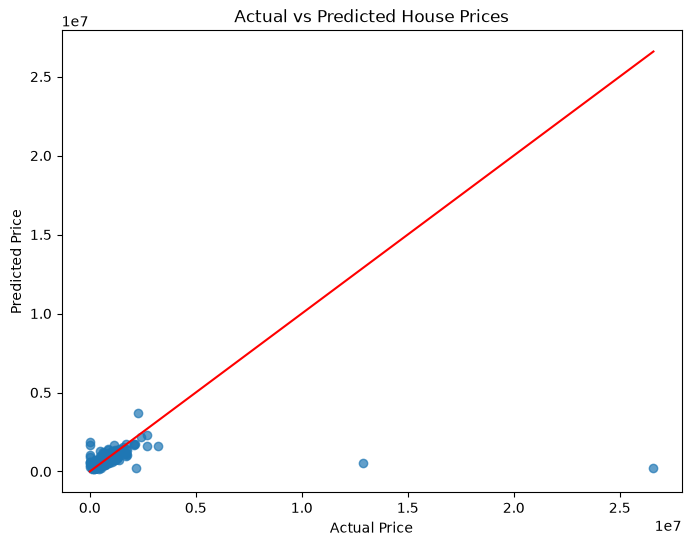

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

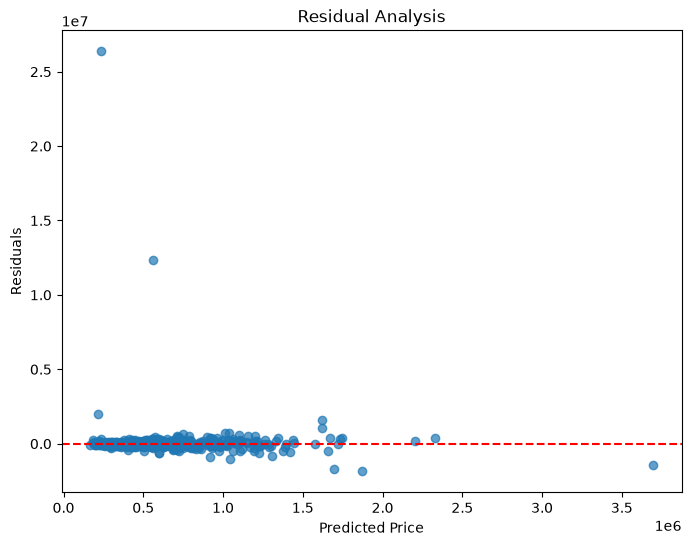

In [36]:
residuals = y_test - best_predictions

plt.figure(figsize=(8,6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.show()

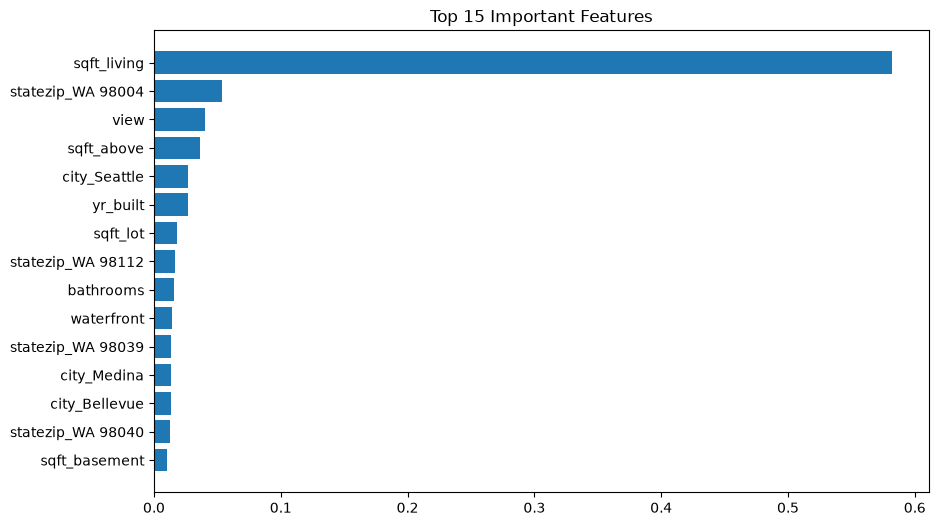

In [37]:
if best_name != "Linear Regression":

    model = best_model.named_steps["model"]

    preprocess = best_model.named_steps["preprocess"]

    ct = preprocess.named_steps["column_transform"]

    feature_names = ct.get_feature_names_out()

    importance = model.feature_importances_

    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    fi = fi.sort_values(
        by="Importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(10,6))

    plt.barh(
        fi["Feature"],
        fi["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title("Top 15 Important Features")

    plt.show()

# Conclusion

The project successfully predicts house prices using machine learning regression models.

Models Compared:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The best-performing model is automatically selected using the highest R² Score and saved for future inference.

The complete workflow includes:

- Data Loading
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Model Comparison
- Model Saving
- Prediction Pipeline

In [38]:
sample = pd.DataFrame([{
    "date": "2014-05-02",
    "bedrooms": 3,
    "bathrooms": 2,
    "sqft_living": 2000,
    "sqft_lot": 5000,
    "floors": 2,
    "waterfront": 0,
    "view": 0,
    "condition": 3,
    "sqft_above": 1800,
    "sqft_basement": 200,
    "yr_built": 2005,
    "yr_renovated": 0,
    "street": "Demo Street",
    "city": "Seattle",
    "statezip": "WA 98119",
    "country": "USA"
}])

prediction = best_model.predict(sample)

print("Predicted House Price : ₹{:,.2f}".format(prediction[0]))

Predicted House Price : ₹671,269.74
